In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [107]:
#to confirm the datatype of the value in date column
# type(df.loc[3]['date'])

def sort_date(x):
    
    parts = x.split('-')
    
    year,month,day = parts
   
    return int(year),int(month),int(day)



In [108]:
#convert numerical months to actual

def numerical_to_name(x):

    mnth = calendar.month_name[x]
    
    return str(mnth)


In [109]:
df = pd.read_csv('fcc-forum-pageviews.csv',parse_dates=['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
# df

df.sort_values(by=['year','month'],ascending=[True,True])
# df

# df.count(numeric_only=True)

,date,value,year,month,day
0,2016-05-09,1201,2016,5,9
1,2016-05-10,2329,2016,5,10
2,2016-05-11,1716,2016,5,11
3,2016-05-12,10539,2016,5,12
4,2016-05-13,6933,2016,5,13
...,...,...,...,...,...
1299,2019-11-29,171584,2019,11,29
1300,2019-11-30,141161,2019,11,30
1301,2019-12-01,142918,2019,12,1
1302,2019-12-02,220144,2019,12,2


In [110]:
df_sorted = df[(df['value']<=df['value'].quantile(0.975)) &
            (df['value']>=df['value'].quantile(0.025))                
            ]

Text(0.5, 0, 'Date')

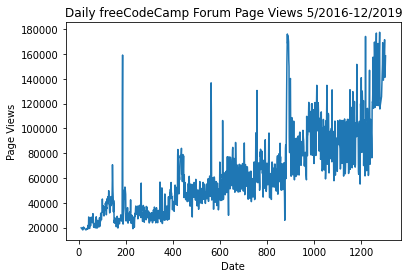

In [111]:
#draw_line_plot
fig,ax = plt.subplots()

ax.plot(df_sorted.index,df_sorted['value'])
ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
ax.set_ylabel('Page Views')
ax.set_xlabel('Date')
# ax.show()
# fig.savefig('line_plot.png')

<AxesSubplot:xlabel='year', ylabel='value'>

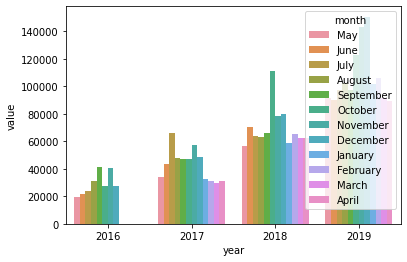

In [112]:
#show average daily page views for each month grouped by year.

# daily_avg_view_per_month = df_new.groupby(['year','month'])
# daily_avg_view_per_month = daily_avg_view_per_month['value'].mean().reset_index()


daily_avg_view_per_month = df_sorted.groupby(['year','month'])['value'].mean().reset_index()
daily_avg_view_per_month['month'] = daily_avg_view_per_month['month'].apply(lambda x:numerical_to_name(x))

# daily_avg_view_per_month
sns.barplot(x='year',y='value',hue='month',data=daily_avg_view_per_month)

In [15]:
#using matplotlib


## BOX-PLOT

<AxesSubplot:title={'center':'value'}, xlabel='year'>

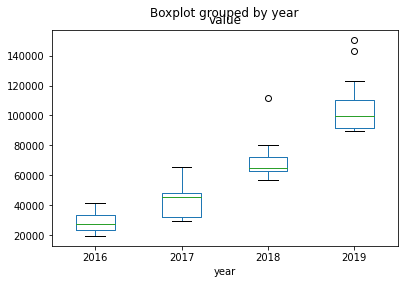

In [16]:
#year wise box plot

daily_avg_view_per_month


daily_avg_view_per_month.boxplot(by='year',column='value',grid=False)


<AxesSubplot:xlabel='year', ylabel='value'>

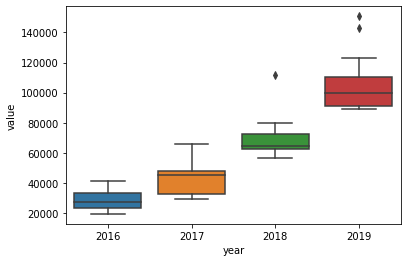

In [17]:
sns.boxplot(x='year',y='value',data=daily_avg_view_per_month)

In [19]:
daily_avg_view_per_month['month'] = daily_avg_view_per_month['month'].apply(lambda x:numerical_to_name(x))


<AxesSubplot:title={'center':'value'}, xlabel='month'>

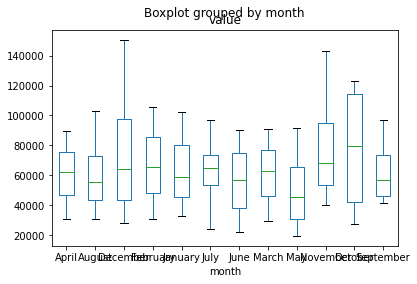

In [181]:
#month wise box plot
daily_avg_view_per_month.boxplot(by='month',column='value',grid=False)

<AxesSubplot:xlabel='month', ylabel='value'>

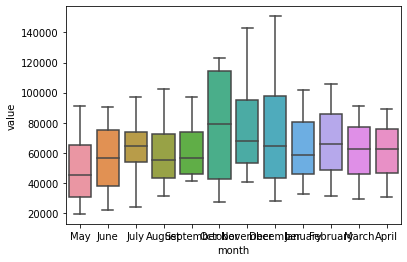

In [182]:
sns.boxplot(x='month',y='value',data=daily_avg_view_per_month)

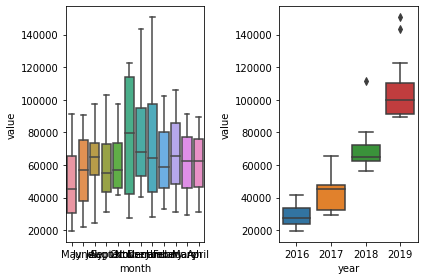

In [183]:
fig, axes = plt.subplots(1, 2)
sns.boxplot(x='month',y='value',data=daily_avg_view_per_month,ax=axes[0])
sns.boxplot(x='year',y='value',data=daily_avg_view_per_month,ax=axes[1])

# plt.tight_layout()

# plt.show()
# fig.savefig('line_plot.png')